# Parte 2: Extracción de Descriptores Clásicos

**Universidad Nacional de Colombia**  
Visión por Computador 3009228 - Semestre 2025-02  
Facultad de Minas - Departamento de Ciencias de la Computación y de la Decisión

---

## Contenido

**A. Descriptores de Forma**
1. Histogram of Oriented Gradients (HOG)
2. Momentos de Hu
3. Descriptores de Contorno
4. Fourier Shape Descriptors

**B. Descriptores de Textura**
1. Local Binary Patterns (LBP)
2. Gray Level Co-occurrence Matrix (GLCM)
3. Filtros de Gabor
4. Estadísticas de Primer Orden

---

## 1. Configuración del Entorno

In [1]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
import sys
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Agregar src al path
sys.path.insert(0, '../src')

# Importar módulos del proyecto - Parte 1
from data_loader import DataLoader
from preprocessing import XRayPreprocessor
from utils import load_image, save_results

# Importar módulos de descriptores - Parte 2
from shape_descriptors import (
    HOGDescriptor, 
    HuMomentsDescriptor, 
    ContourDescriptor, 
    FourierShapeDescriptor,
    ShapeDescriptorExtractor
)
from texture_descriptors import (
    LBPDescriptor, 
    GLCMDescriptor, 
    GaborDescriptor, 
    FirstOrderStatistics,
    TextureDescriptorExtractor
)

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✓ Módulos importados correctamente")

✓ Módulos importados correctamente


In [2]:
# Configuración de rutas
DATA_ROOT = Path('../data/chest-xray-pneumonia/chest_xray')
RESULTS_DIR = Path('../results/descriptors')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Cargar datos
loader = DataLoader(DATA_ROOT)
image_paths = loader.get_image_paths()

# Crear preprocesador
preprocessor = XRayPreprocessor(
    target_size=(224, 224),
    apply_clahe=True,
    clahe_clip_limit=2.0,
    normalize=False  # Mantener uint8 para descriptores
)

print(f"✓ Dataset cargado: {len(image_paths['train']['NORMAL'])} NORMAL, {len(image_paths['train']['PNEUMONIA'])} PNEUMONIA")

✓ Dataset cargado: 1341 NORMAL, 3875 PNEUMONIA


In [3]:
# Cargar y preprocesar imágenes de muestra
def load_and_preprocess(path):
    """Carga y preprocesa una imagen."""
    img = loader.load_image(path)
    img_resized = preprocessor.resize(img)
    img_clahe = preprocessor.apply_clahe_enhancement(img_resized)
    return img_clahe

# Cargar muestras
sample_normal = load_and_preprocess(image_paths['train']['NORMAL'][0])
sample_pneumonia = load_and_preprocess(image_paths['train']['PNEUMONIA'][0])

print(f"Imagen NORMAL preprocesada: {sample_normal.shape}, dtype: {sample_normal.dtype}")
print(f"Imagen PNEUMONIA preprocesada: {sample_pneumonia.shape}, dtype: {sample_pneumonia.dtype}")

Imagen NORMAL preprocesada: (224, 224), dtype: uint8
Imagen PNEUMONIA preprocesada: (224, 224), dtype: uint8


---

# PARTE A: DESCRIPTORES DE FORMA

---

## 2. Histogram of Oriented Gradients (HOG)

### Fundamentos

HOG captura la distribución de direcciones de gradientes locales:

1. **Dividir imagen en celdas** (ej. 8x8 píxeles)
2. **Calcular gradientes** en cada píxel
3. **Crear histograma de orientaciones** por celda
4. **Normalizar por bloques** para invarianza a iluminación

### Parámetros:
- `pixels_per_cell`: Tamaño de celda (menor = más detalle)
- `cells_per_block`: Celdas por bloque para normalización
- `orientations`: Número de bins de dirección (típico: 9 = 20° por bin)

In [4]:
# Crear descriptor HOG
hog_descriptor = HOGDescriptor(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
)

# Extraer con visualización
hog_normal = hog_descriptor.extract(sample_normal, visualize=True)
hog_pneumonia = hog_descriptor.extract(sample_pneumonia, visualize=True)

print(f"HOG NORMAL: {hog_normal['n_features']} características")
print(f"HOG PNEUMONIA: {hog_pneumonia['n_features']} características")

HOG NORMAL: 26244 características
HOG PNEUMONIA: 26244 características


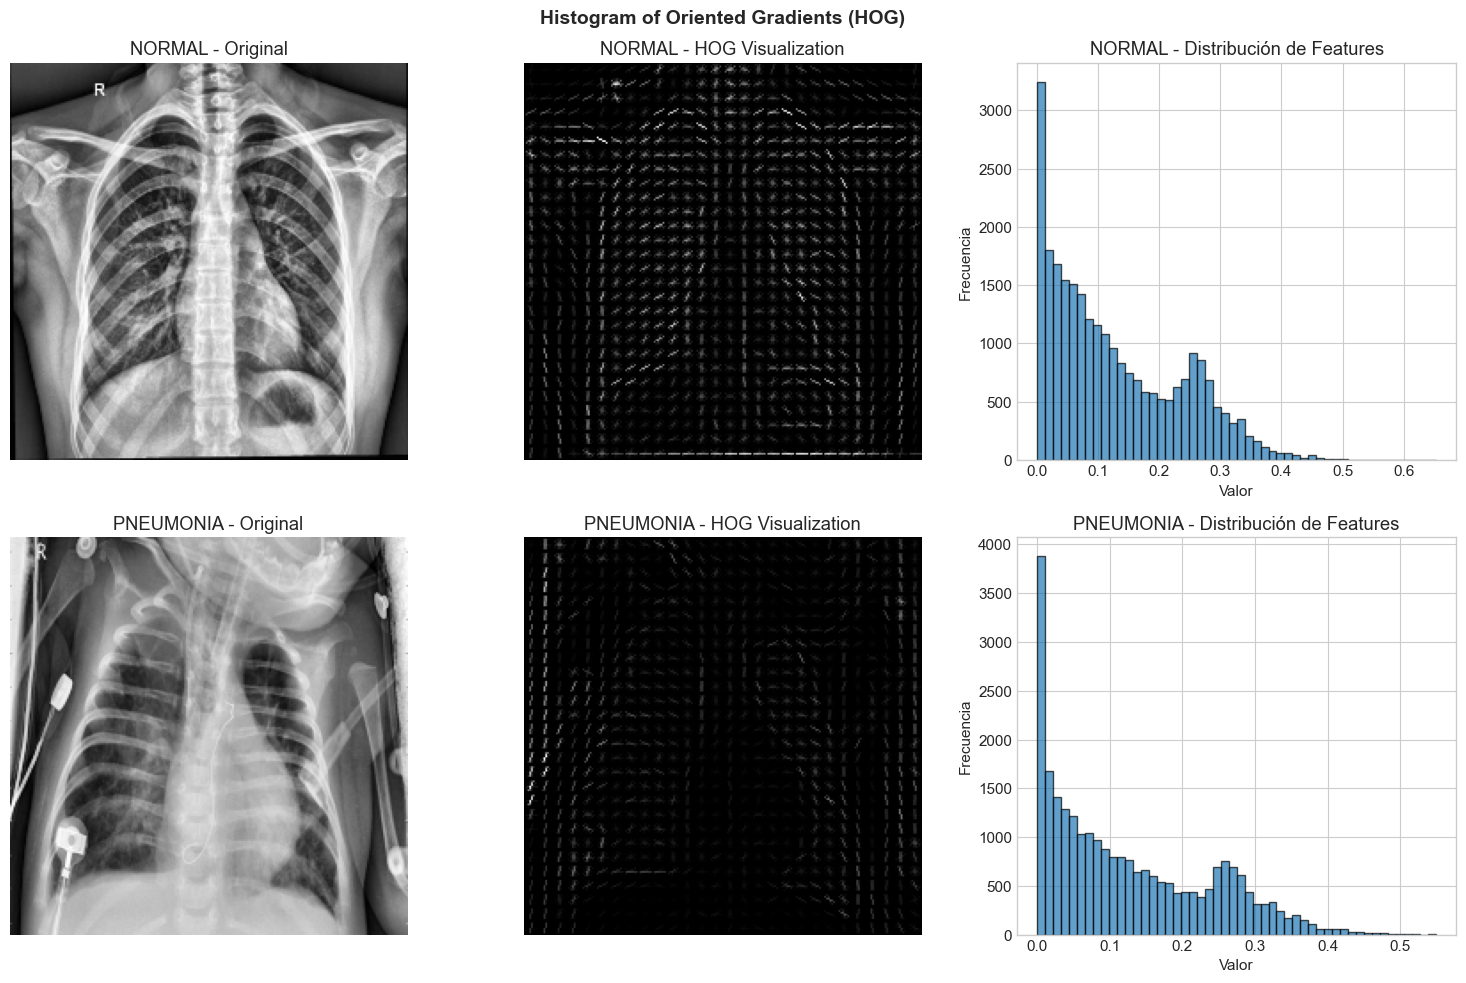

In [5]:
# Visualizar descriptores HOG
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Histogram of Oriented Gradients (HOG)', fontsize=14, fontweight='bold')

for row, (name, img, hog_result) in enumerate([
    ('NORMAL', sample_normal, hog_normal),
    ('PNEUMONIA', sample_pneumonia, hog_pneumonia)
]):
    # Imagen original
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{name} - Original')
    axes[row, 0].axis('off')
    
    # Visualización HOG
    axes[row, 1].imshow(hog_result['visualization'], cmap='gray')
    axes[row, 1].set_title(f'{name} - HOG Visualization')
    axes[row, 1].axis('off')
    
    # Histograma de features
    axes[row, 2].hist(hog_result['features'], bins=50, alpha=0.7, edgecolor='black')
    axes[row, 2].set_title(f'{name} - Distribución de Features')
    axes[row, 2].set_xlabel('Valor')
    axes[row, 2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hog_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

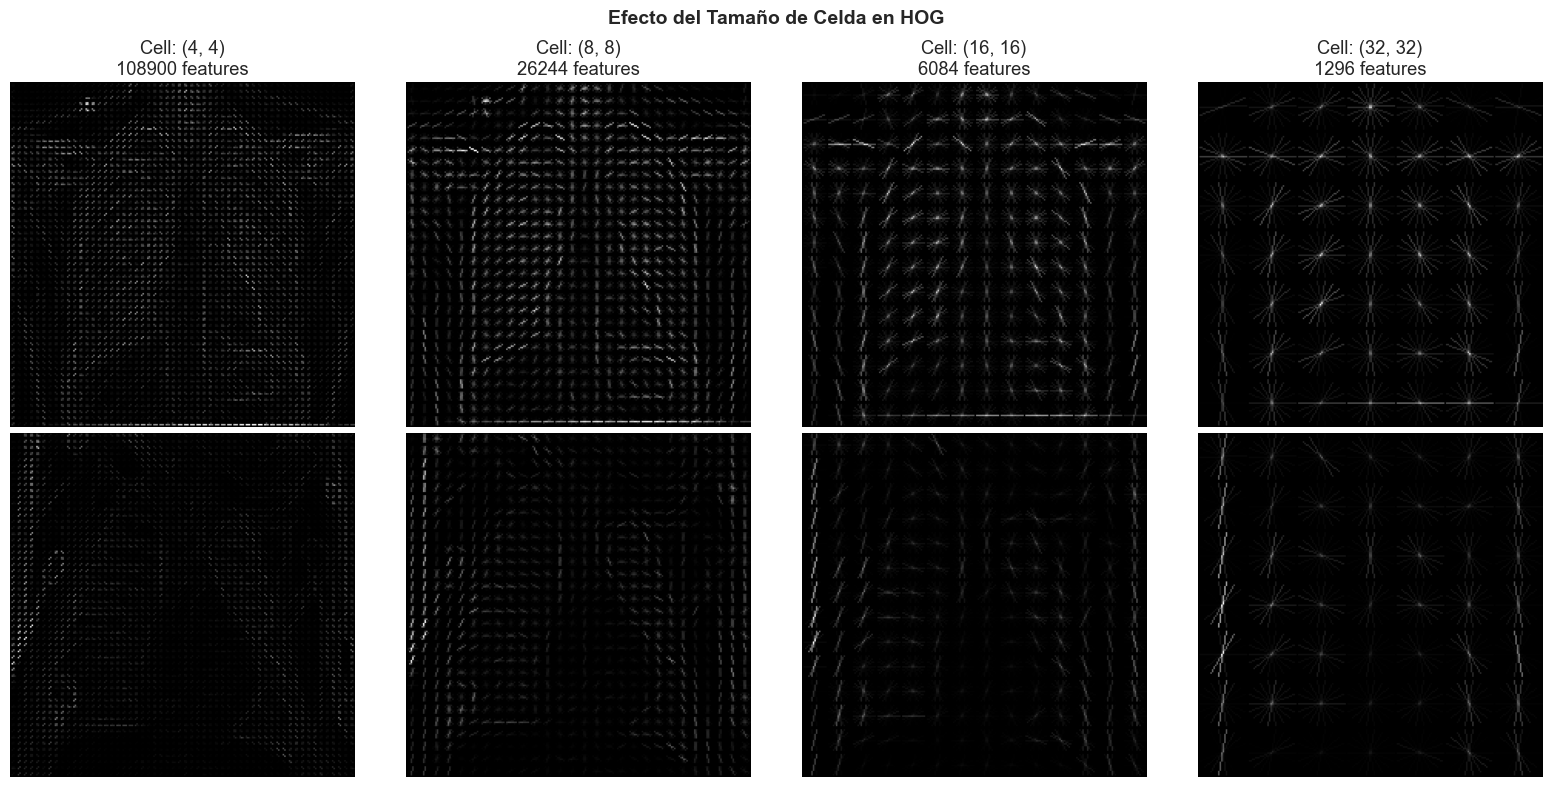

In [6]:
# Experimentar con diferentes tamaños de celda
cell_sizes = [(4, 4), (8, 8), (16, 16), (32, 32)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Efecto del Tamaño de Celda en HOG', fontsize=14, fontweight='bold')

for idx, cell_size in enumerate(cell_sizes):
    hog = HOGDescriptor(pixels_per_cell=cell_size)
    
    result_normal = hog.extract(sample_normal, visualize=True)
    result_pneumonia = hog.extract(sample_pneumonia, visualize=True)
    
    axes[0, idx].imshow(result_normal['visualization'], cmap='gray')
    axes[0, idx].set_title(f'Cell: {cell_size}\n{result_normal["n_features"]} features')
    axes[0, idx].axis('off')
    
    axes[1, idx].imshow(result_pneumonia['visualization'], cmap='gray')
    axes[1, idx].axis('off')

axes[0, 0].set_ylabel('NORMAL', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('PNEUMONIA', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hog_cell_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Obtener estadísticas HOG para reducir dimensionalidad
hog_stats_normal = hog_descriptor.get_statistics(hog_normal['features'])
hog_stats_pneumonia = hog_descriptor.get_statistics(hog_pneumonia['features'])

print("Estadísticas HOG:")
print(f"\n{'Métrica':<20} {'NORMAL':>12} {'PNEUMONIA':>12}")
print("-" * 45)
for key in hog_stats_normal:
    print(f"{key:<20} {hog_stats_normal[key]:>12.4f} {hog_stats_pneumonia[key]:>12.4f}")

Estadísticas HOG:

Métrica                    NORMAL    PNEUMONIA
---------------------------------------------
mean                       0.1280       0.1254
std                        0.1067       0.1098
min                        0.0000       0.0000
max                        0.6530       0.5492
median                     0.0991       0.0953
q25                        0.0378       0.0297
q75                        0.2121       0.2110
skewness                   0.7384       0.7231
kurtosis                  -0.3120      -0.4728


## 3. Momentos de Hu

### Fundamentos

Los 7 momentos de Hu son **invariantes a rotación, escala y traslación**:

| Momento | Descripción | Invarianza |
|---------|-------------|------------|
| h1 | Momento de inercia | Rotación, escala, traslación |
| h2 | Elongación de la forma | Rotación, escala, traslación |
| h3-h6 | Momentos de orden superior | Rotación, escala, traslación |
| h7 | Distingue formas especulares | Cambia signo con reflexión |

In [8]:
# Crear descriptor de momentos de Hu
hu_descriptor = HuMomentsDescriptor(log_transform=True)

# Extraer momentos
hu_normal = hu_descriptor.extract(sample_normal)
hu_pneumonia = hu_descriptor.extract(sample_pneumonia)

# Mostrar explicación de invarianzas
print(hu_descriptor.explain_invariances())

Momentos de Hu - Invarianzas:

Los 7 momentos de Hu son invariantes a:
- Traslación: No dependen de la posición del objeto
- Escala: No dependen del tamaño del objeto
- Rotación: No dependen de la orientación del objeto

Momento 7 es invariante a rotación pero cambia de signo con reflexión,
lo que permite distinguir entre formas especulares.

La transformación logarítmica reduce el rango de valores y mejora
la estabilidad numérica.


In [9]:
# Comparar momentos entre clases
print("\nMomentos de Hu (transformados log):")
print(f"\n{'Momento':<10} {'NORMAL':>15} {'PNEUMONIA':>15} {'Diferencia':>15}")
print("-" * 60)
for i in range(1, 8):
    key = f'hu_{i}'
    diff = abs(hu_normal[key] - hu_pneumonia[key])
    print(f"{key:<10} {hu_normal[key]:>15.4f} {hu_pneumonia[key]:>15.4f} {diff:>15.4f}")


Momentos de Hu (transformados log):

Momento             NORMAL       PNEUMONIA      Diferencia
------------------------------------------------------------
hu_1                2.9397          2.9163          0.0234
hu_2                9.1972          7.7654          1.4318
hu_3                9.9960          9.9820          0.0140
hu_4                9.9869          9.9847          0.0022
hu_5              -10.0000         10.0000         20.0000
hu_6               10.0000        -10.0000         20.0000
hu_7              -10.0000        -10.0000          0.0000


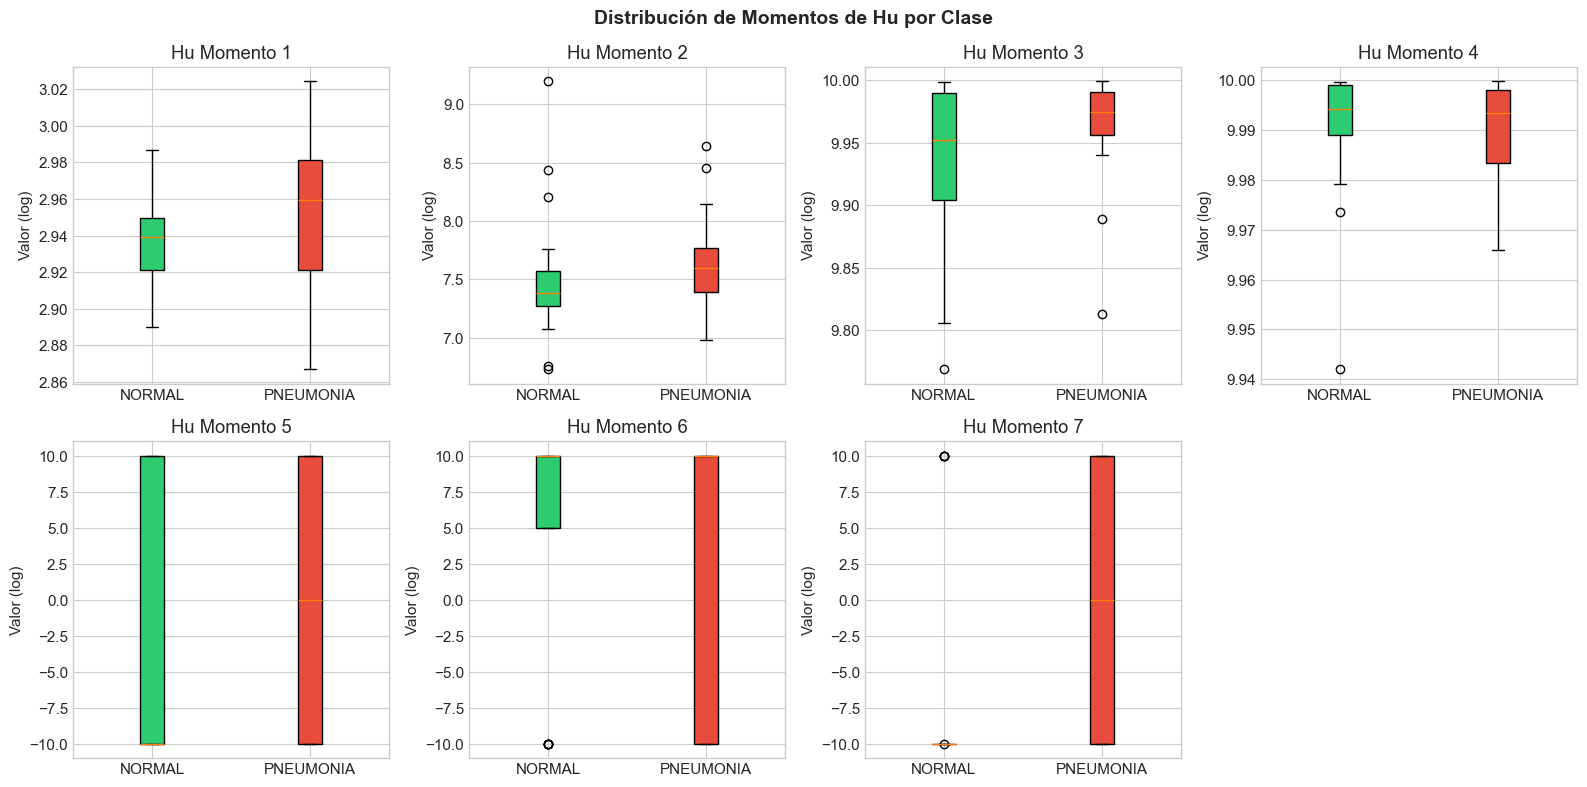

In [10]:
# Visualizar momentos de Hu para múltiples muestras
n_samples = 20
hu_values = {'NORMAL': [], 'PNEUMONIA': []}

for class_name in ['NORMAL', 'PNEUMONIA']:
    for path in image_paths['train'][class_name][:n_samples]:
        img = load_and_preprocess(path)
        hu = hu_descriptor.extract(img)
        hu_values[class_name].append([hu[f'hu_{i}'] for i in range(1, 8)])

hu_normal_arr = np.array(hu_values['NORMAL'])
hu_pneumonia_arr = np.array(hu_values['PNEUMONIA'])

# Visualizar
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución de Momentos de Hu por Clase', fontsize=14, fontweight='bold')

for i in range(7):
    row, col = i // 4, i % 4
    
    data = [hu_normal_arr[:, i], hu_pneumonia_arr[:, i]]
    bp = axes[row, col].boxplot(data, labels=['NORMAL', 'PNEUMONIA'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    axes[row, col].set_title(f'Hu Momento {i+1}')
    axes[row, col].set_ylabel('Valor (log)')

axes[1, 3].axis('off')  # Ocultar subplot vacío

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hu_moments_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Descriptores de Contorno

### Métricas implementadas:

- **Área**: Número de píxeles dentro del contorno
- **Perímetro**: Longitud del contorno
- **Circularidad**: 4π × área / perímetro² (círculo = 1)
- **Excentricidad**: Elongación de la forma (0 = círculo)
- **Solidez**: Área / Área convexa

In [11]:
# Crear descriptor de contorno
contour_descriptor = ContourDescriptor(min_area=100)

# Extraer descriptores
contour_normal = contour_descriptor.extract(sample_normal)
contour_pneumonia = contour_descriptor.extract(sample_pneumonia)

print("Descriptores de Contorno:")
print(f"\n{'Métrica':<25} {'NORMAL':>12} {'PNEUMONIA':>12}")
print("-" * 50)
for key in contour_normal:
    print(f"{key:<25} {contour_normal[key]:>12.4f} {contour_pneumonia[key]:>12.4f}")

Descriptores de Contorno:

Métrica                         NORMAL    PNEUMONIA
--------------------------------------------------
contour_area                10842.0000    6883.0000
contour_perimeter            2009.1757     764.5584
contour_circularity             0.0338       0.1480
contour_eccentricity               nan          nan
contour_solidity                0.2180       0.6523
contour_centroid_x            101.2686     200.4260
contour_centroid_y             86.3843     109.1155
n_contours                      8.0000       5.0000


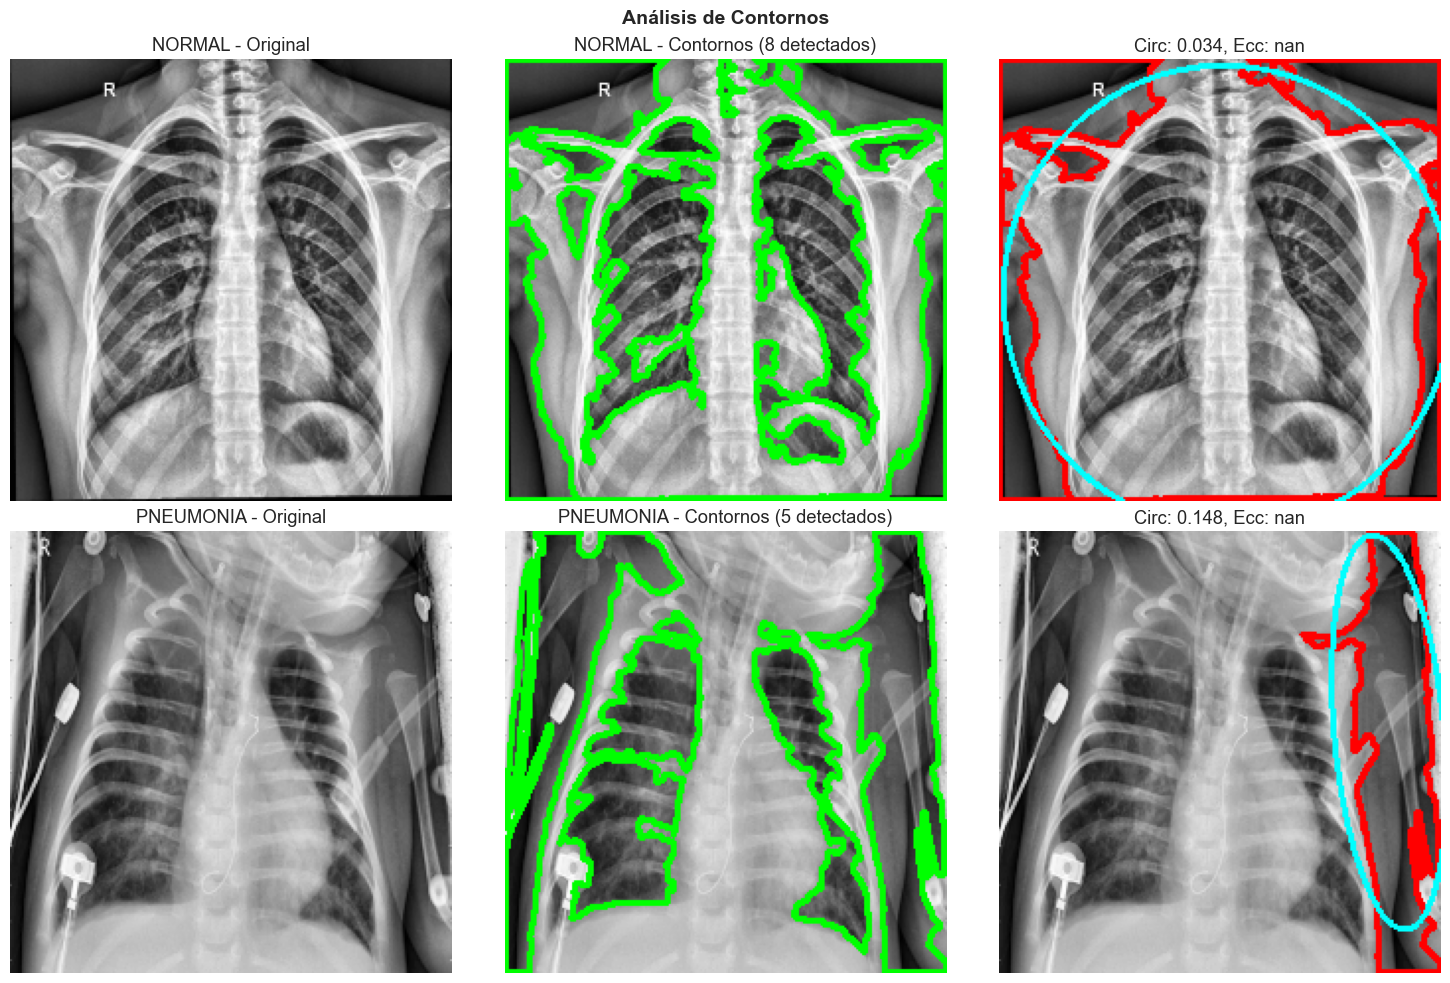

In [12]:
# Visualizar contornos detectados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análisis de Contornos', fontsize=14, fontweight='bold')

for row, (name, img) in enumerate([('NORMAL', sample_normal), ('PNEUMONIA', sample_pneumonia)]):
    # Imagen original
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{name} - Original')
    axes[row, 0].axis('off')
    
    # Extraer contornos
    contours = contour_descriptor.extract_contours(img)
    
    # Dibujar contornos
    img_contours = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)
    axes[row, 1].imshow(img_contours)
    axes[row, 1].set_title(f'{name} - Contornos ({len(contours)} detectados)')
    axes[row, 1].axis('off')
    
    # Contorno principal con métricas
    if contours:
        main_contour = max(contours, key=cv2.contourArea)
        img_main = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        cv2.drawContours(img_main, [main_contour], -1, (255, 0, 0), 2)
        
        # Ajustar elipse
        if len(main_contour) >= 5:
            ellipse = cv2.fitEllipse(main_contour)
            cv2.ellipse(img_main, ellipse, (0, 255, 255), 2)
        
        axes[row, 2].imshow(img_main)
        metrics = contour_descriptor.extract_from_contour(main_contour)
        axes[row, 2].set_title(f'Circ: {metrics["contour_circularity"]:.3f}, Ecc: {metrics["contour_eccentricity"]:.3f}')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'contour_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Fourier Shape Descriptors

### Fundamentos

La transformada de Fourier del contorno representa la forma en el dominio de frecuencia:

- **Coeficientes de baja frecuencia**: Forma general
- **Coeficientes de alta frecuencia**: Detalles finos

Ventajas:
- Representación compacta (primeros N coeficientes)
- Invarianza a traslación (ignorando F[0])
- Invarianza a escala (normalizando por |F[1]|)

In [13]:
# Crear descriptor de Fourier
fourier_descriptor = FourierShapeDescriptor(n_coefficients=20, normalize=True)

# Extraer descriptores
fourier_normal = fourier_descriptor.extract(sample_normal)
fourier_pneumonia = fourier_descriptor.extract(sample_pneumonia)

print(f"Features de Fourier extraídos: {len([k for k in fourier_normal if 'fourier' in k])}")

Features de Fourier extraídos: 23


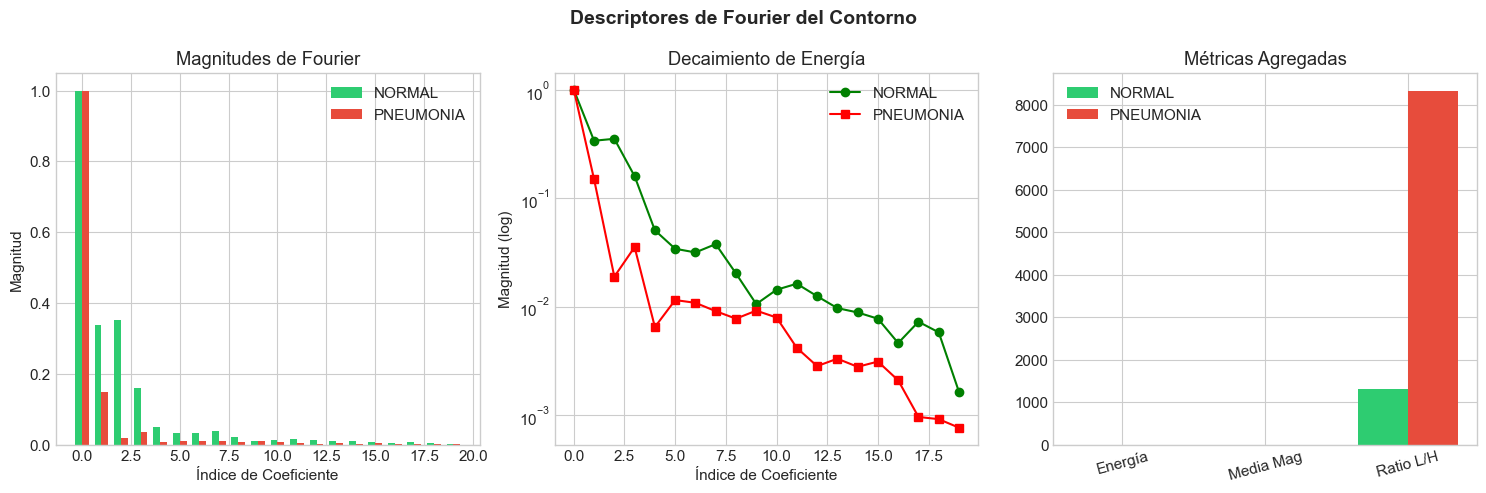

In [14]:
# Visualizar coeficientes de Fourier
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Descriptores de Fourier del Contorno', fontsize=14, fontweight='bold')

# Magnitudes
mags_normal = [fourier_normal[f'fourier_mag_{i}'] for i in range(20)]
mags_pneumonia = [fourier_pneumonia[f'fourier_mag_{i}'] for i in range(20)]

x = np.arange(20)
width = 0.35

axes[0].bar(x - width/2, mags_normal, width, label='NORMAL', color='#2ecc71')
axes[0].bar(x + width/2, mags_pneumonia, width, label='PNEUMONIA', color='#e74c3c')
axes[0].set_xlabel('Índice de Coeficiente')
axes[0].set_ylabel('Magnitud')
axes[0].set_title('Magnitudes de Fourier')
axes[0].legend()

# Energía por frecuencia
axes[1].semilogy(mags_normal, 'g-o', label='NORMAL')
axes[1].semilogy(mags_pneumonia, 'r-s', label='PNEUMONIA')
axes[1].set_xlabel('Índice de Coeficiente')
axes[1].set_ylabel('Magnitud (log)')
axes[1].set_title('Decaimiento de Energía')
axes[1].legend()
axes[1].grid(True)

# Métricas agregadas
metrics = ['fourier_energy', 'fourier_mean_mag', 'fourier_low_high_ratio']
normal_vals = [fourier_normal[m] for m in metrics]
pneumonia_vals = [fourier_pneumonia[m] for m in metrics]

x = np.arange(len(metrics))
axes[2].bar(x - width/2, normal_vals, width, label='NORMAL', color='#2ecc71')
axes[2].bar(x + width/2, pneumonia_vals, width, label='PNEUMONIA', color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Energía', 'Media Mag', 'Ratio L/H'], rotation=15)
axes[2].set_title('Métricas Agregadas')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fourier_descriptors.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE B: DESCRIPTORES DE TEXTURA

---

## 6. Local Binary Patterns (LBP)

### Fundamentos

LBP compara cada píxel con sus vecinos:

1. Para cada píxel central, comparar con P vecinos en radio R
2. Si vecino ≥ centro → bit = 1, sino → bit = 0
3. Concatenar bits para formar código LBP
4. Crear histograma de códigos

### Variantes:
- **uniform**: Solo patrones con ≤2 transiciones (reduce bins)
- **rotation-invariant**: Invariante a rotación

In [15]:
# Crear descriptor LBP
lbp_descriptor = LBPDescriptor(radius=3, n_points=24, method='uniform')

# Calcular imágenes LBP
lbp_img_normal = lbp_descriptor.compute_lbp(sample_normal)
lbp_img_pneumonia = lbp_descriptor.compute_lbp(sample_pneumonia)

# Extraer features
lbp_normal = lbp_descriptor.extract(sample_normal)
lbp_pneumonia = lbp_descriptor.extract(sample_pneumonia)

print(f"Features LBP extraídos: {len(lbp_normal)}")

Features LBP extraídos: 13


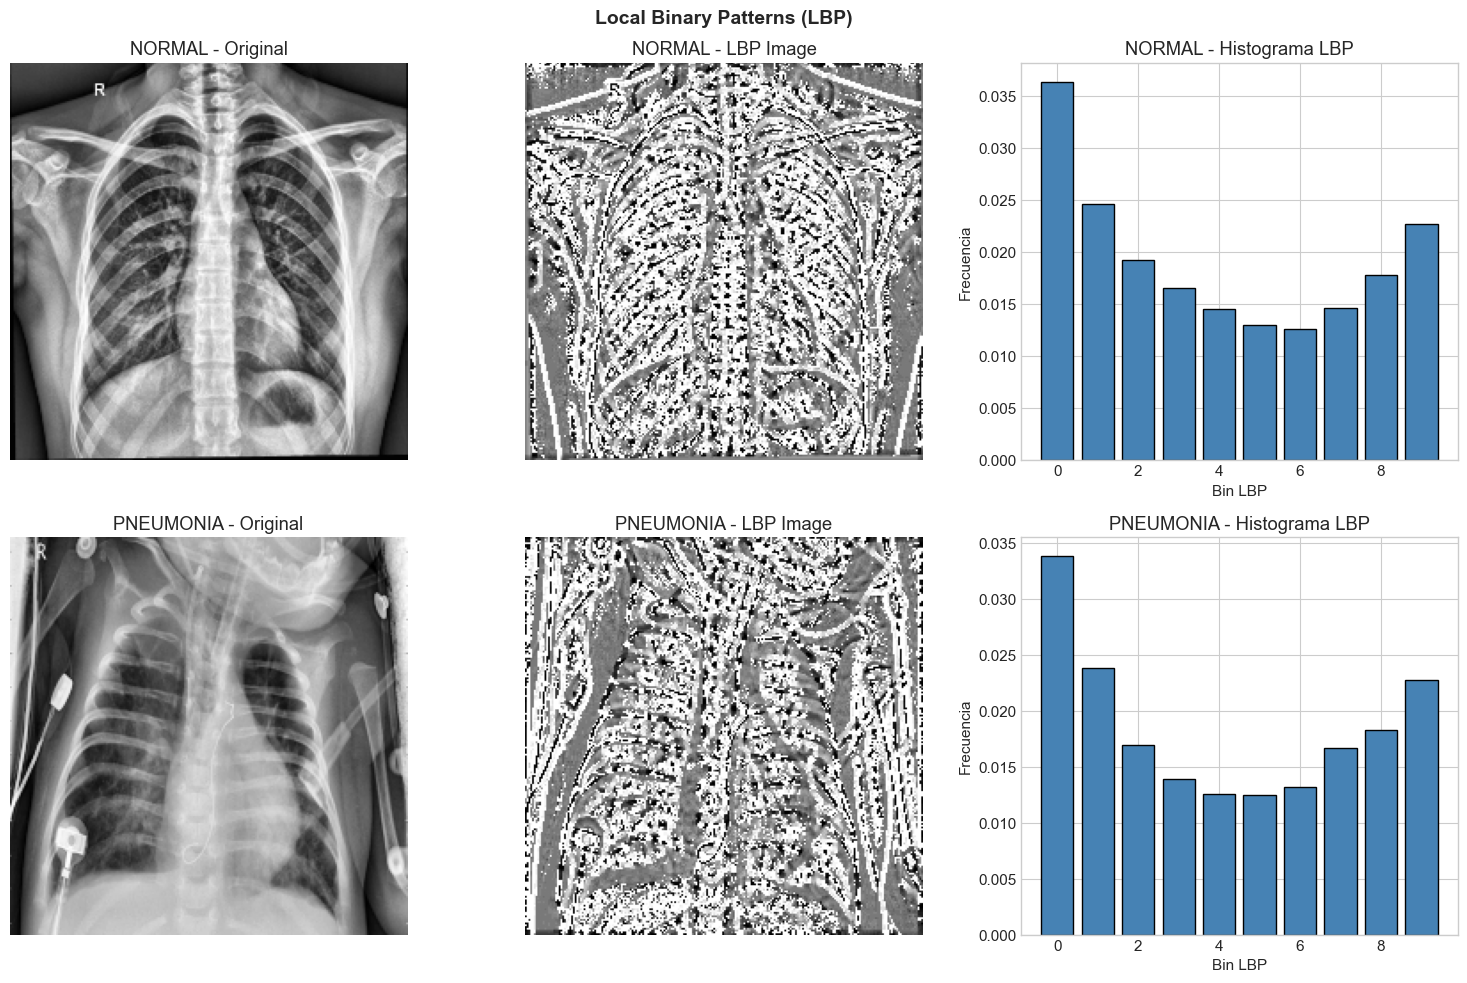

In [16]:
# Visualizar LBP
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Local Binary Patterns (LBP)', fontsize=14, fontweight='bold')

for row, (name, img, lbp_img, lbp_feat) in enumerate([
    ('NORMAL', sample_normal, lbp_img_normal, lbp_normal),
    ('PNEUMONIA', sample_pneumonia, lbp_img_pneumonia, lbp_pneumonia)
]):
    # Original
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{name} - Original')
    axes[row, 0].axis('off')
    
    # LBP
    axes[row, 1].imshow(lbp_img, cmap='gray')
    axes[row, 1].set_title(f'{name} - LBP Image')
    axes[row, 1].axis('off')
    
    # Histograma
    bins = [lbp_feat[f'lbp_bin_{i}'] for i in range(10)]
    axes[row, 2].bar(range(10), bins, color='steelblue', edgecolor='black')
    axes[row, 2].set_xlabel('Bin LBP')
    axes[row, 2].set_ylabel('Frecuencia')
    axes[row, 2].set_title(f'{name} - Histograma LBP')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lbp_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

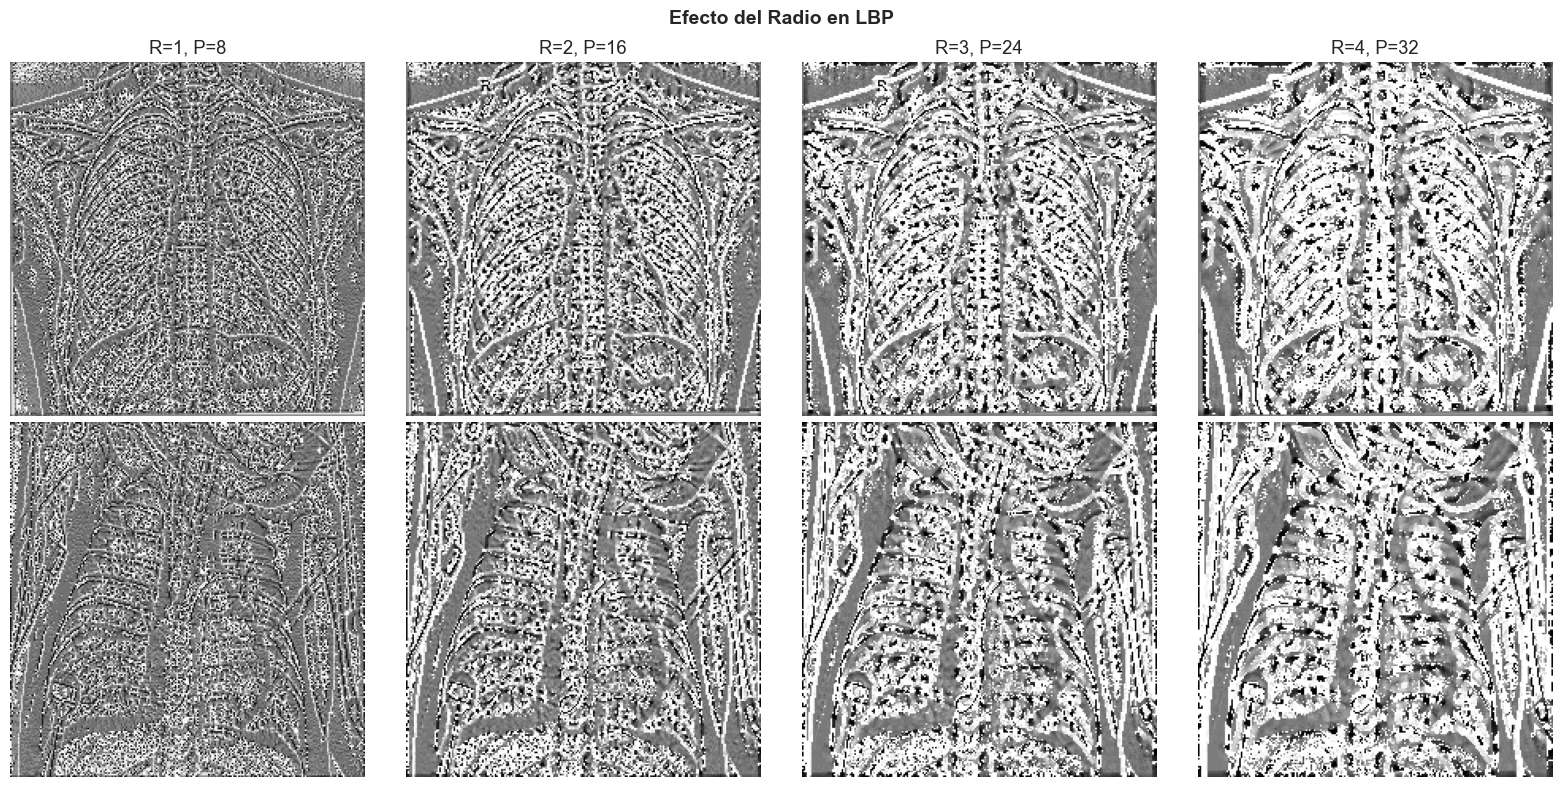

In [17]:
# Experimentar con diferentes radios
radii = [1, 2, 3, 4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Efecto del Radio en LBP', fontsize=14, fontweight='bold')

for idx, radius in enumerate(radii):
    lbp = LBPDescriptor(radius=radius, n_points=8*radius, method='uniform')
    
    lbp_img_n = lbp.compute_lbp(sample_normal)
    lbp_img_p = lbp.compute_lbp(sample_pneumonia)
    
    axes[0, idx].imshow(lbp_img_n, cmap='gray')
    axes[0, idx].set_title(f'R={radius}, P={8*radius}')
    axes[0, idx].axis('off')
    
    axes[1, idx].imshow(lbp_img_p, cmap='gray')
    axes[1, idx].axis('off')

axes[0, 0].set_ylabel('NORMAL', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('PNEUMONIA', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lbp_radii.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Gray Level Co-occurrence Matrix (GLCM)

### Fundamentos

GLCM cuenta la frecuencia de pares de píxeles con valores (i, j) a una distancia y dirección dadas.

### Propiedades:

| Propiedad | Descripción |
|-----------|-------------|
| **Contraste** | Variación local de intensidad |
| **Correlación** | Dependencia lineal entre píxeles |
| **Energía** | Uniformidad (suma de cuadrados) |
| **Homogeneidad** | Cercanía a la diagonal |

In [18]:
# Crear descriptor GLCM
glcm_descriptor = GLCMDescriptor(
    distances=[1, 3, 5],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]
)

# Extraer features
glcm_normal = glcm_descriptor.extract(sample_normal)
glcm_pneumonia = glcm_descriptor.extract(sample_pneumonia)

print("Propiedades GLCM:")
print(f"\n{'Propiedad':<30} {'NORMAL':>12} {'PNEUMONIA':>12}")
print("-" * 55)
for key in ['glcm_contrast_mean', 'glcm_correlation_mean', 'glcm_energy_mean', 'glcm_homogeneity_mean']:
    print(f"{key:<30} {glcm_normal[key]:>12.4f} {glcm_pneumonia[key]:>12.4f}")

Propiedades GLCM:

Propiedad                            NORMAL    PNEUMONIA
-------------------------------------------------------
glcm_contrast_mean                  83.9191      62.4817
glcm_correlation_mean                0.8166       0.8417
glcm_energy_mean                     0.0308       0.0418
glcm_homogeneity_mean                0.2287       0.3027


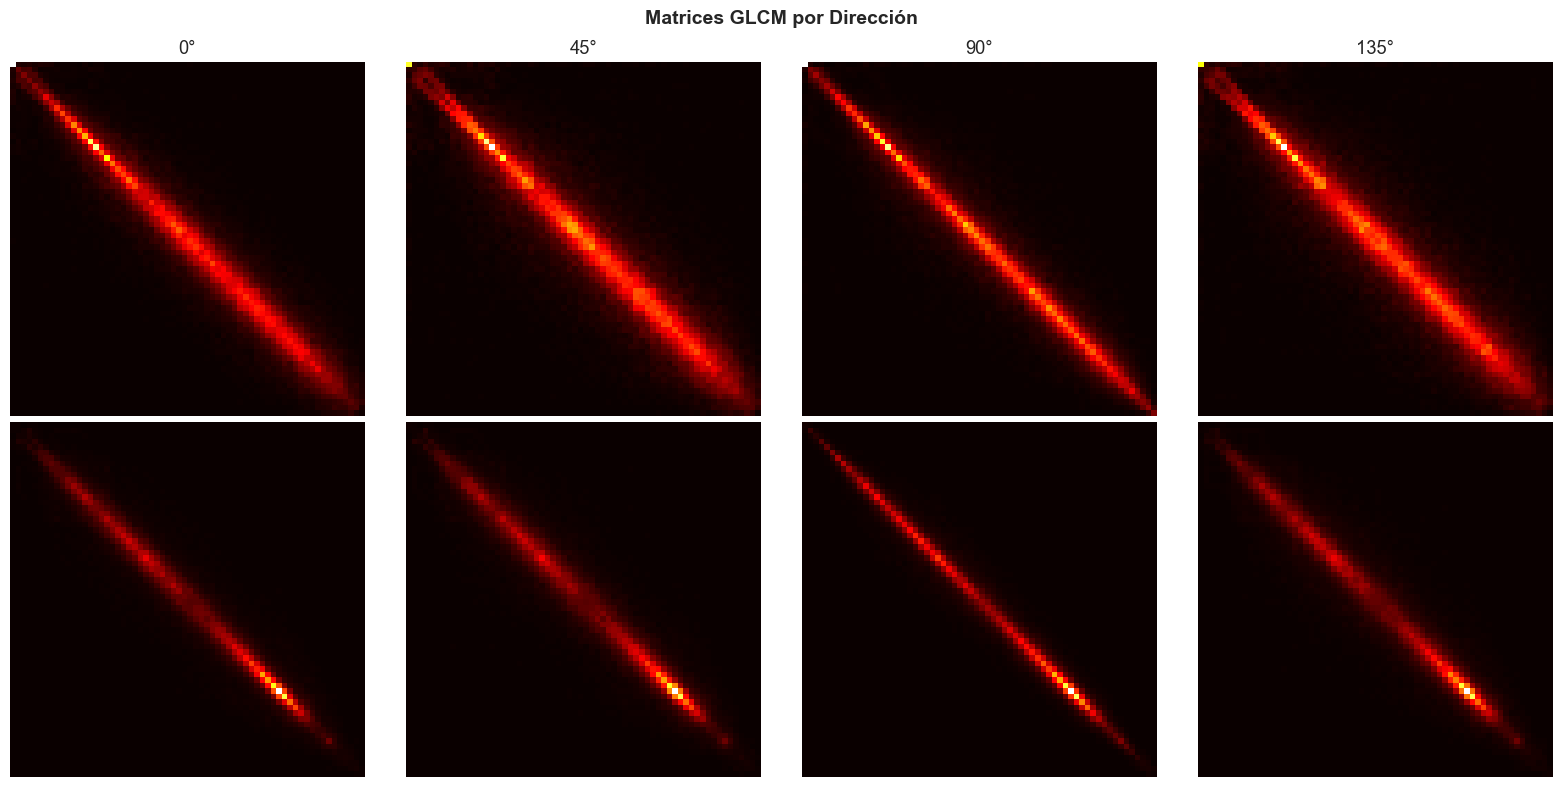

In [19]:
# Visualizar matriz GLCM
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Matrices GLCM por Dirección', fontsize=14, fontweight='bold')

angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
angle_names = ['0°', '45°', '90°', '135°']

for row, (name, img) in enumerate([('NORMAL', sample_normal), ('PNEUMONIA', sample_pneumonia)]):
    for col, (angle, angle_name) in enumerate(zip(angles, angle_names)):
        # Calcular GLCM desde cero para visualizar
        glcm_matrix = glcm_descriptor.compute_glcm_from_scratch(img, distance=1, angle=angle)
        
        im = axes[row, col].imshow(glcm_matrix, cmap='hot')
        axes[row, col].set_title(f'{angle_name}' if row == 0 else '')
        axes[row, col].axis('off')
        
        if col == 0:
            axes[row, col].set_ylabel(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'glcm_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

PNEUMONIA: 100%|██████████| 30/30 [00:00<00:00, 132.77it/s]


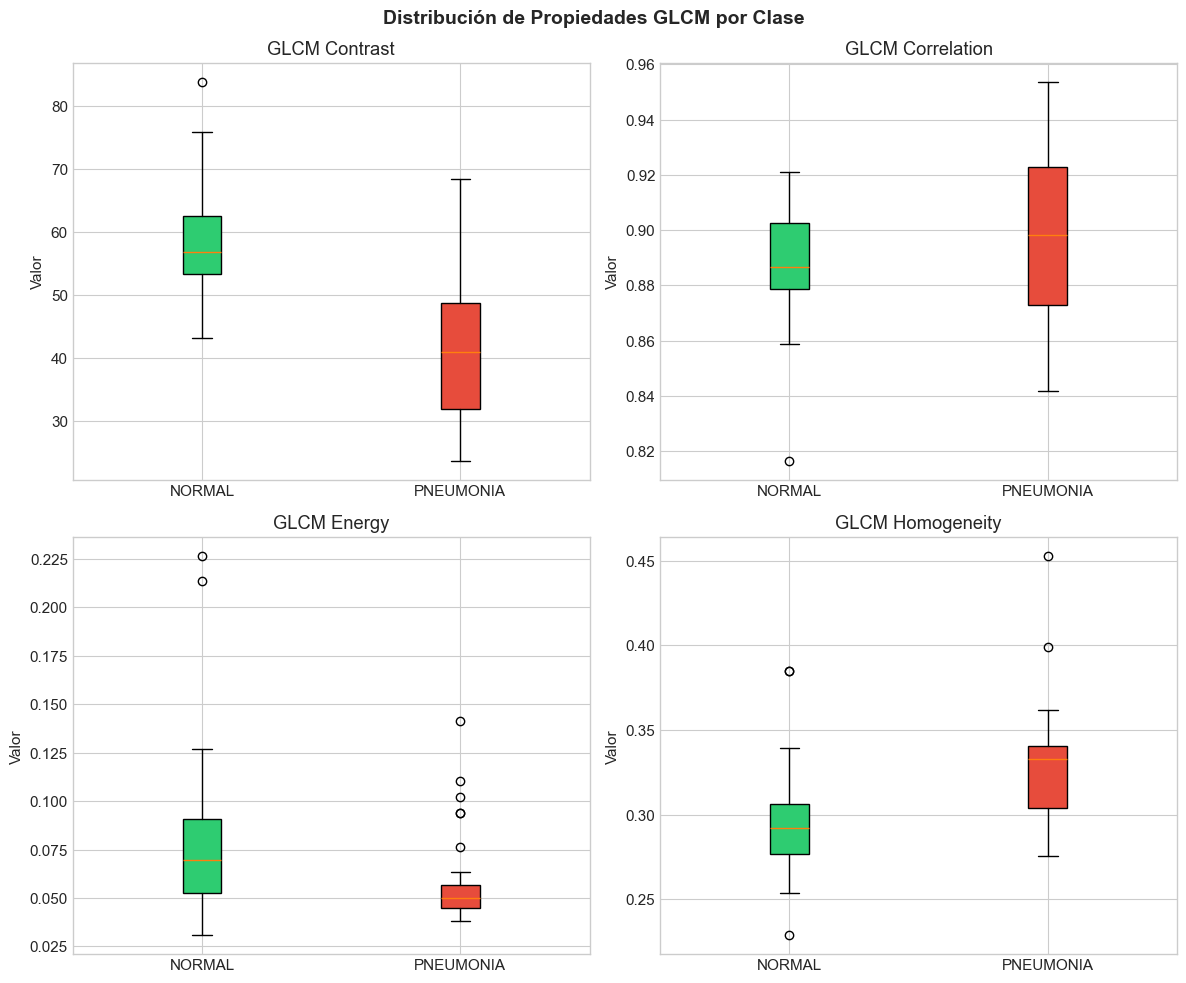

In [20]:
# Comparar propiedades GLCM entre clases
n_samples = 30
glcm_features = {'NORMAL': [], 'PNEUMONIA': []}

for class_name in ['NORMAL', 'PNEUMONIA']:
    for path in tqdm(image_paths['train'][class_name][:n_samples], desc=class_name):
        img = load_and_preprocess(path)
        features = glcm_descriptor.extract(img)
        glcm_features[class_name].append(features)

# Visualizar distribución de propiedades
properties = ['contrast', 'correlation', 'energy', 'homogeneity']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribución de Propiedades GLCM por Clase', fontsize=14, fontweight='bold')

for idx, prop in enumerate(properties):
    row, col = idx // 2, idx % 2
    
    normal_vals = [f[f'glcm_{prop}_mean'] for f in glcm_features['NORMAL']]
    pneumonia_vals = [f[f'glcm_{prop}_mean'] for f in glcm_features['PNEUMONIA']]
    
    bp = axes[row, col].boxplot([normal_vals, pneumonia_vals], 
                                 labels=['NORMAL', 'PNEUMONIA'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    axes[row, col].set_title(f'GLCM {prop.capitalize()}')
    axes[row, col].set_ylabel('Valor')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'glcm_properties_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Filtros de Gabor

### Fundamentos

Los filtros de Gabor son sinusoides moduladas por gaussiana, sensibles a:
- **Frecuencia espacial**: Escala del patrón
- **Orientación**: Dirección del patrón

Un banco de filtros con múltiples frecuencias y orientaciones captura texturas a diferentes escalas.

In [21]:
# Crear descriptor de Gabor
gabor_descriptor = GaborDescriptor(
    frequencies=[0.1, 0.2, 0.3, 0.4],
    orientations=[0, np.pi/4, np.pi/2, 3*np.pi/4]
)

# Aplicar filtros
responses_normal = gabor_descriptor.apply_filters(sample_normal)
responses_pneumonia = gabor_descriptor.apply_filters(sample_pneumonia)

print(f"Número de filtros aplicados: {len(responses_normal)}")

Número de filtros aplicados: 16


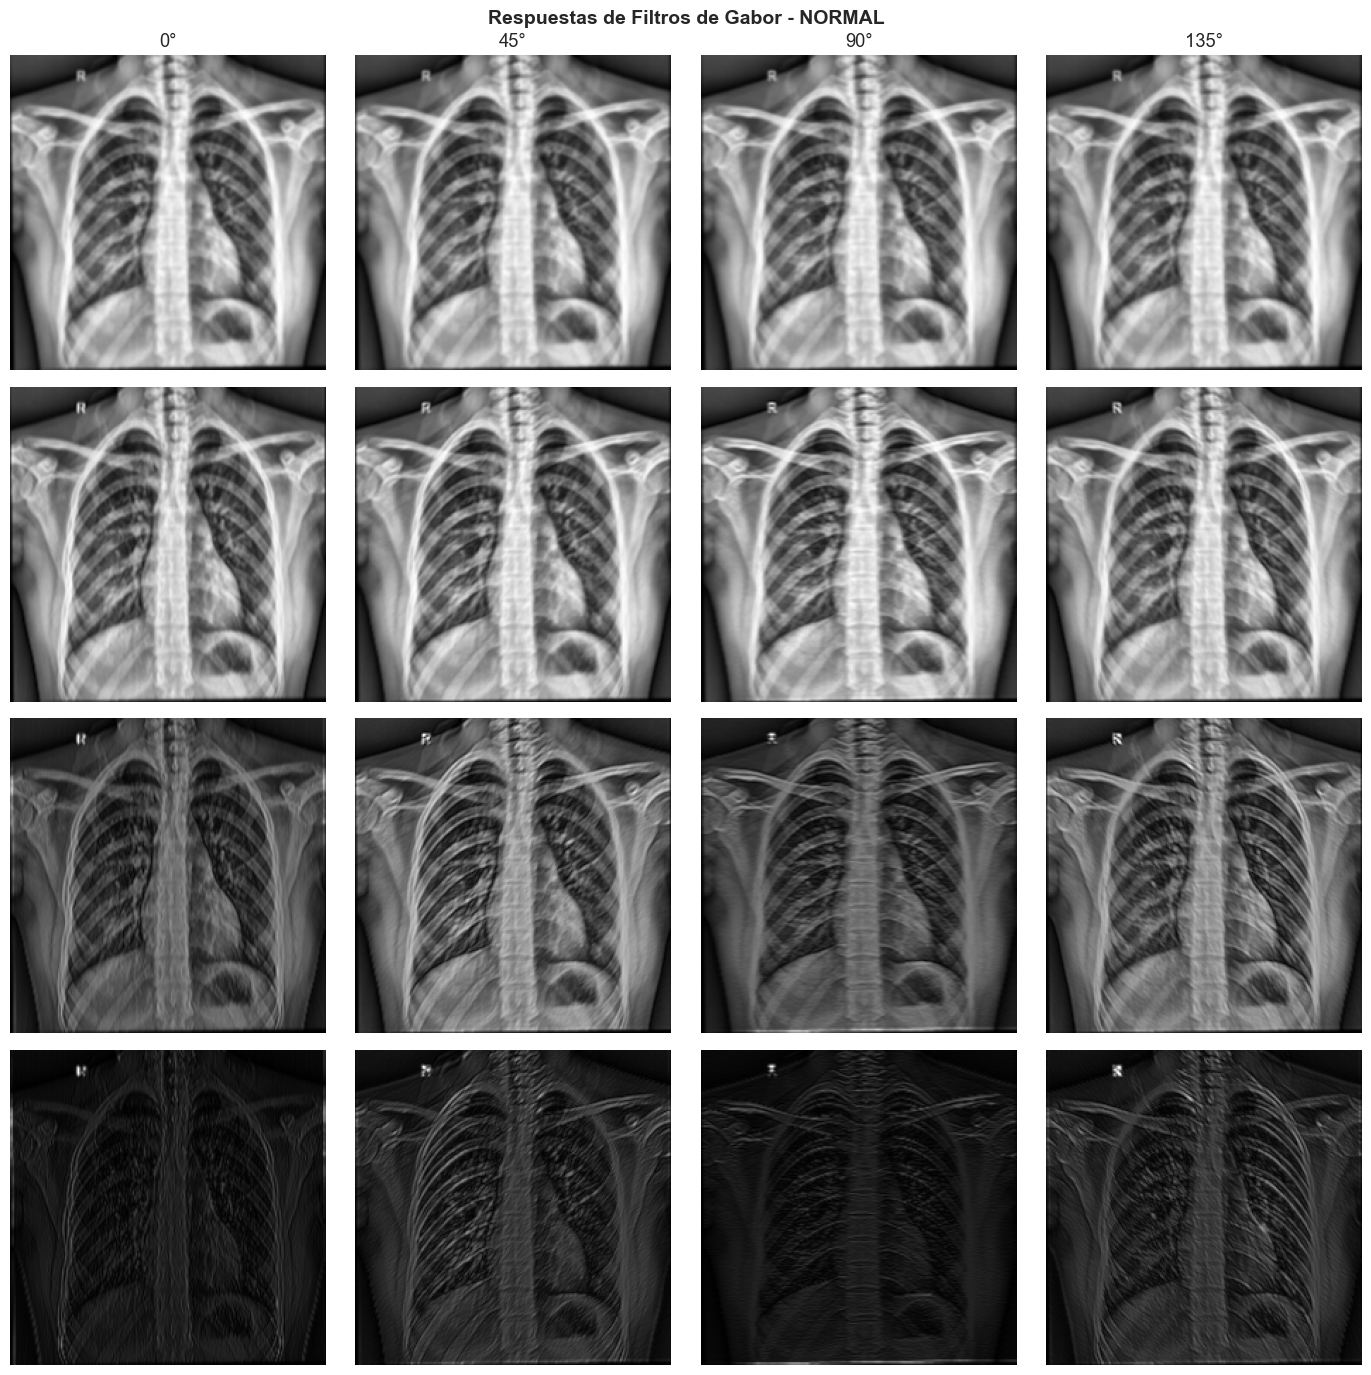

In [22]:
# Visualizar banco de filtros de Gabor
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Respuestas de Filtros de Gabor - NORMAL', fontsize=14, fontweight='bold')

frequencies = [0.1, 0.2, 0.3, 0.4]
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
orientation_names = ['0°', '45°', '90°', '135°']

for f_idx, freq in enumerate(frequencies):
    for o_idx, (orient, o_name) in enumerate(zip(orientations, orientation_names)):
        response_idx = f_idx * len(orientations) + o_idx
        
        axes[f_idx, o_idx].imshow(responses_normal[response_idx], cmap='gray')
        if f_idx == 0:
            axes[f_idx, o_idx].set_title(o_name)
        if o_idx == 0:
            axes[f_idx, o_idx].set_ylabel(f'f={freq}')
        axes[f_idx, o_idx].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gabor_responses_normal.png', dpi=150, bbox_inches='tight')
plt.show()

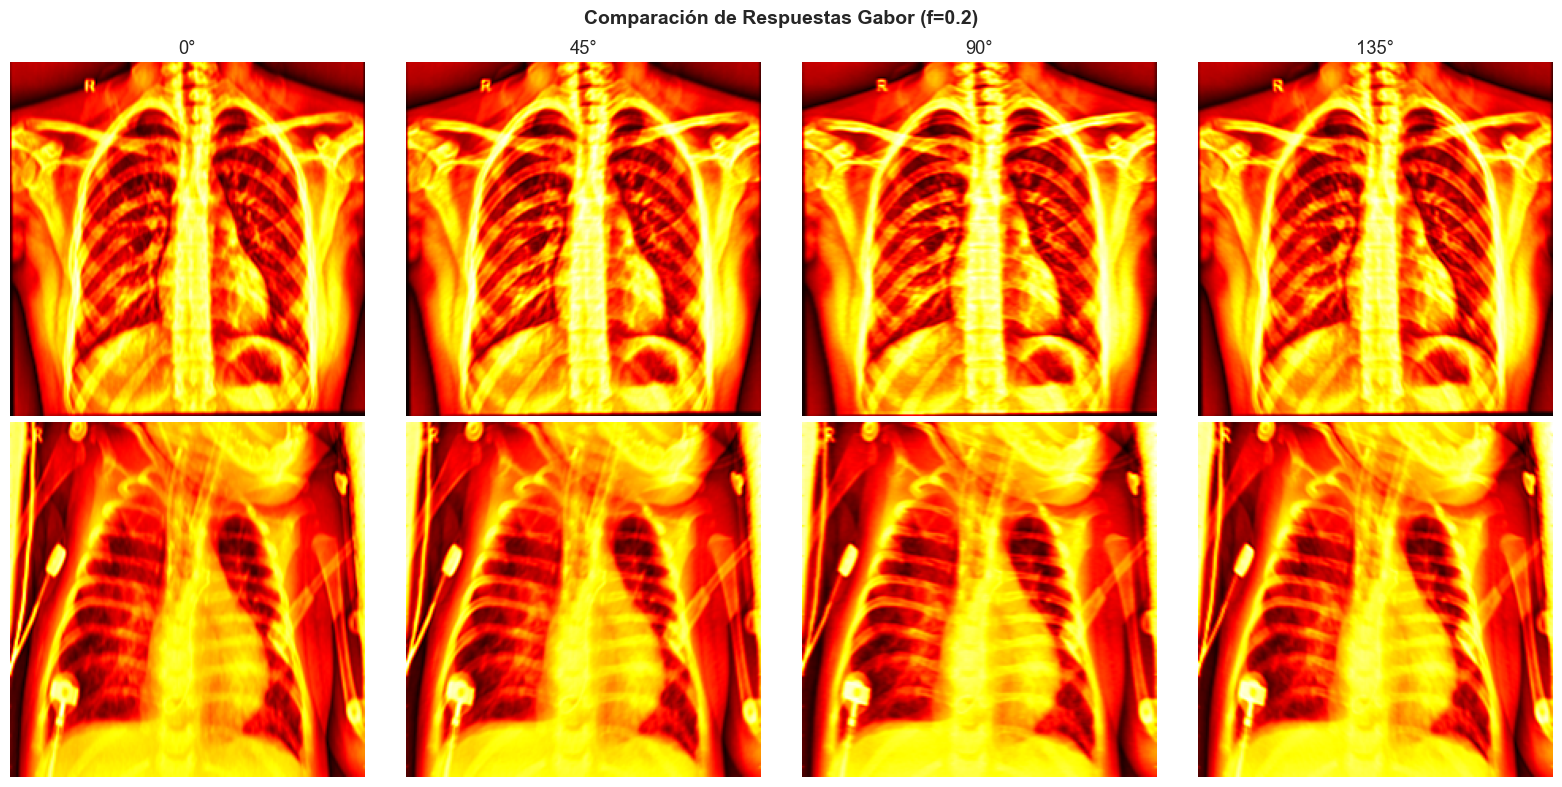

In [23]:
# Comparar respuestas entre clases
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Comparación de Respuestas Gabor (f=0.2)', fontsize=14, fontweight='bold')

# Índices para f=0.2
freq_idx = 1
start_idx = freq_idx * 4

for o_idx, o_name in enumerate(orientation_names):
    axes[0, o_idx].imshow(responses_normal[start_idx + o_idx], cmap='hot')
    axes[0, o_idx].set_title(o_name)
    axes[0, o_idx].axis('off')
    
    axes[1, o_idx].imshow(responses_pneumonia[start_idx + o_idx], cmap='hot')
    axes[1, o_idx].axis('off')

axes[0, 0].set_ylabel('NORMAL', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('PNEUMONIA', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gabor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Extraer features compactos
gabor_normal = gabor_descriptor.extract_compact(sample_normal)
gabor_pneumonia = gabor_descriptor.extract_compact(sample_pneumonia)

print("Features de Gabor (compactos):")
print(f"\n{'Feature':<25} {'NORMAL':>12} {'PNEUMONIA':>12}")
print("-" * 50)
for key in gabor_normal:
    print(f"{key:<25} {gabor_normal[key]:>12.4f} {gabor_pneumonia[key]:>12.4f}")

Features de Gabor (compactos):

Feature                         NORMAL    PNEUMONIA
--------------------------------------------------
gabor_0_mean                    0.4250       0.4317
gabor_0_std                     0.1882       0.1760
gabor_0_max                     0.8000       0.8162
gabor_0_var                     0.0354       0.0310
gabor_1_mean                    0.4251       0.4315
gabor_1_std                     0.1881       0.1756
gabor_1_max                     0.7988       0.8158
gabor_1_var                     0.0354       0.0309
gabor_2_mean                    0.4250       0.4311
gabor_2_std                     0.1880       0.1752
gabor_2_max                     0.7991       0.8147
gabor_2_var                     0.0353       0.0307
gabor_3_mean                    0.4251       0.4314
gabor_3_std                     0.1881       0.1756
gabor_3_max                     0.8003       0.8153
gabor_3_var                     0.0354       0.0308
gabor_4_mean                    0

## 9. Estadísticas de Primer Orden

### Métricas implementadas:

- **Media, varianza**: Nivel de brillo y contraste
- **Skewness**: Asimetría de la distribución
- **Kurtosis**: Peso de las colas
- **Entropía**: Complejidad de la textura

In [25]:
# Crear descriptor de estadísticas
stats_descriptor = FirstOrderStatistics()

# Extraer estadísticas
stats_normal = stats_descriptor.extract(sample_normal)
stats_pneumonia = stats_descriptor.extract(sample_pneumonia)

print("Estadísticas de Primer Orden:")
print(f"\n{'Estadística':<20} {'NORMAL':>12} {'PNEUMONIA':>12}")
print("-" * 45)
for key in ['stat_mean', 'stat_std', 'stat_skewness', 'stat_kurtosis', 'stat_entropy']:
    print(f"{key:<20} {stats_normal[key]:>12.4f} {stats_pneumonia[key]:>12.4f}")

Estadísticas de Primer Orden:

Estadística                NORMAL    PNEUMONIA
---------------------------------------------
stat_mean                  0.5169       0.5249
stat_std                   0.2403       0.2223
stat_skewness             -0.1067      -0.2178
stat_kurtosis             -0.9253      -1.0633
stat_entropy             -36.6973     -76.3297


PNEUMONIA: 100%|██████████| 50/50 [00:00<00:00, 121.51it/s]


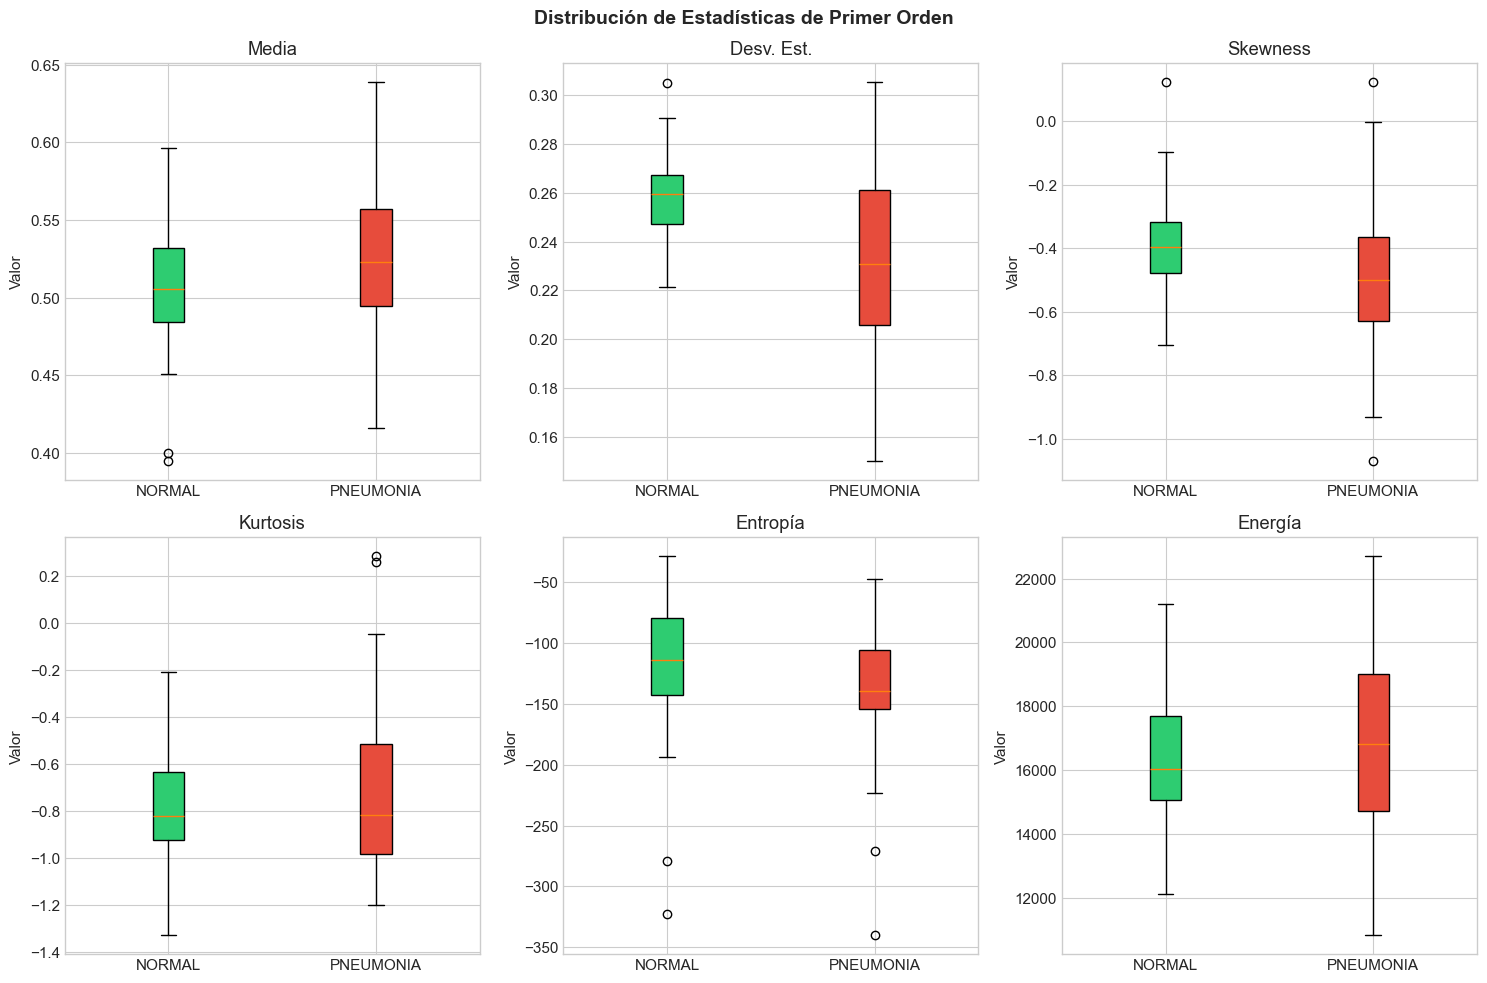

In [26]:
# Visualizar estadísticas para múltiples muestras
n_samples = 50
all_stats = {'NORMAL': [], 'PNEUMONIA': []}

for class_name in ['NORMAL', 'PNEUMONIA']:
    for path in tqdm(image_paths['train'][class_name][:n_samples], desc=class_name):
        img = load_and_preprocess(path)
        stats = stats_descriptor.extract(img)
        all_stats[class_name].append(stats)

# Visualizar
metrics = ['stat_mean', 'stat_std', 'stat_skewness', 'stat_kurtosis', 'stat_entropy', 'stat_energy']
metric_names = ['Media', 'Desv. Est.', 'Skewness', 'Kurtosis', 'Entropía', 'Energía']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribución de Estadísticas de Primer Orden', fontsize=14, fontweight='bold')

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    row, col = idx // 3, idx % 3
    
    normal_vals = [s[metric] for s in all_stats['NORMAL']]
    pneumonia_vals = [s[metric] for s in all_stats['PNEUMONIA']]
    
    bp = axes[row, col].boxplot([normal_vals, pneumonia_vals], 
                                 labels=['NORMAL', 'PNEUMONIA'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    axes[row, col].set_title(name)
    axes[row, col].set_ylabel('Valor')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'first_order_stats.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 10. Extracción Combinada de Descriptores

In [27]:
# Crear extractores unificados
shape_extractor = ShapeDescriptorExtractor(
    use_hog=True,
    use_hu=True,
    use_contour=True,
    use_fourier=True
)

texture_extractor = TextureDescriptorExtractor(
    use_lbp=True,
    use_glcm=True,
    use_gabor=True,
    use_stats=True
)

# Extraer todos los features
shape_features = shape_extractor.extract(sample_normal)
texture_features = texture_extractor.extract(sample_normal)

print(f"Features de Forma: {len(shape_features)}")
print(f"Features de Textura: {len(texture_features)}")
print(f"Total: {len(shape_features) + len(texture_features)}")

Features de Forma: 47
Features de Textura: 132
Total: 179


In [28]:
# Procesar conjunto de imágenes completo
n_train = 100  # Muestras por clase

X_shape = []
X_texture = []
y = []

for class_idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    paths = image_paths['train'][class_name][:n_train]
    
    for path in tqdm(paths, desc=f'Procesando {class_name}'):
        img = load_and_preprocess(path)
        
        shape_feat = shape_extractor.extract(img)
        texture_feat = texture_extractor.extract(img)
        
        X_shape.append(list(shape_feat.values()))
        X_texture.append(list(texture_feat.values()))
        y.append(class_idx)

X_shape = np.array(X_shape)
X_texture = np.array(X_texture)
X_combined = np.hstack([X_shape, X_texture])
y = np.array(y)

print(f"\nDimensiones:")
print(f"  Shape features: {X_shape.shape}")
print(f"  Texture features: {X_texture.shape}")
print(f"  Combined: {X_combined.shape}")

Procesando PNEUMONIA: 100%|██████████| 100/100 [00:06<00:00, 15.21it/s]


Dimensiones:
  Shape features: (200, 47)
  Texture features: (200, 132)
  Combined: (200, 179)


In [29]:
# Guardar resultados
results = {
    'n_samples': len(y),
    'n_shape_features': X_shape.shape[1],
    'n_texture_features': X_texture.shape[1],
    'n_total_features': X_combined.shape[1],
    'shape_feature_names': list(shape_features.keys()),
    'texture_feature_names': list(texture_features.keys())
}

save_results(results, RESULTS_DIR / 'descriptor_summary.json')

# Guardar features para clasificación
np.save(RESULTS_DIR / 'X_shape.npy', X_shape)
np.save(RESULTS_DIR / 'X_texture.npy', X_texture)
np.save(RESULTS_DIR / 'X_combined.npy', X_combined)
np.save(RESULTS_DIR / 'y_labels.npy', y)

print(f"✓ Resultados guardados en {RESULTS_DIR}")

✓ Resultados guardados en ../results/descriptors


---

## 11. Resumen

In [30]:
print("=" * 70)
print("RESUMEN - PARTE 2: EXTRACCIÓN DE DESCRIPTORES")
print("=" * 70)

print("\n📐 DESCRIPTORES DE FORMA:")
print("   • HOG: Captura distribución de gradientes orientados")
print("   • Momentos de Hu: 7 momentos invariantes a rotación/escala")
print("   • Contorno: Área, perímetro, circularidad, excentricidad")
print("   • Fourier: Representación en frecuencia del contorno")

print("\n🎨 DESCRIPTORES DE TEXTURA:")
print("   • LBP: Patrones binarios locales (robusto a iluminación)")
print("   • GLCM: Matriz de co-ocurrencia (contraste, correlación, energía)")
print("   • Gabor: Banco de filtros multi-frecuencia/orientación")
print("   • Estadísticas: Media, varianza, skewness, kurtosis, entropía")

print(f"\n📊 FEATURES EXTRAÍDOS:")
print(f"   • Forma: {X_shape.shape[1]} características")
print(f"   • Textura: {X_texture.shape[1]} características")
print(f"   • Total: {X_combined.shape[1]} características")

print("\n" + "=" * 70)

RESUMEN - PARTE 2: EXTRACCIÓN DE DESCRIPTORES

📐 DESCRIPTORES DE FORMA:
   • HOG: Captura distribución de gradientes orientados
   • Momentos de Hu: 7 momentos invariantes a rotación/escala
   • Contorno: Área, perímetro, circularidad, excentricidad
   • Fourier: Representación en frecuencia del contorno

🎨 DESCRIPTORES DE TEXTURA:
   • LBP: Patrones binarios locales (robusto a iluminación)
   • GLCM: Matriz de co-ocurrencia (contraste, correlación, energía)
   • Gabor: Banco de filtros multi-frecuencia/orientación
   • Estadísticas: Media, varianza, skewness, kurtosis, entropía

📊 FEATURES EXTRAÍDOS:
   • Forma: 47 características
   • Textura: 132 características
   • Total: 179 características



---

## Referencias

1. Dalal, N., & Triggs, B. (2005). Histograms of oriented gradients for human detection. CVPR.
2. Hu, M. K. (1962). Visual pattern recognition by moment invariants. IRE transactions on information theory.
3. Ojala, T., Pietikainen, M., & Maenpaa, T. (2002). Multiresolution gray-scale and rotation invariant texture classification with local binary patterns. IEEE TPAMI.
4. Haralick, R. M., et al. (1973). Textural features for image classification. IEEE Transactions on systems, man, and cybernetics.

---

**Siguiente paso:** Clasificación y evaluación de modelos